# Proximal Point Method (PPM) for monotone inclusion

This notebook applies the systematic Lyapunov-function discovery procedure 
to the proximal point method $x_{k+1}=J_A x_k$ where $A$ is maximally monotone. 
The targeted convergence rate is the tight guarantee 
$\|\tilde{A}x_{N+1}\|^2 = \|x_N-x_{N+1}\|^2\le \frac{\|x_0-x_\star\|^2}{(1+1/N)^N(N+1)}$, 
provided in "Tight sublinear convergence rate of the proximal point algorithm for maximal
monotone inclusion problems" by Gu and Yang (2020).

## Import the required libraries

In [1]:
import pepflow as pf
import pepflow.lyapunov_utils as lu
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import itertools
from IPython.display import display, Math

## Define the operators

In [2]:
A = pf.MonotoneOperator(is_basis=True, tags=["A"])

## Write a function that generates a PEPContext object associated with PPM

In [3]:
def make_ctx_proximal_point_method(ctx_name: str, N: int | sp.Integer) -> pf.PEPContext:
    ctx_ppm = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    A.set_zero_point("x_star")

    # We construct x_1, ..., x_{N+1}; the performance metric uses x_N and x_{N+1}.
    for i in range(int(N) + 1):
        x = A.resolvent(x, sp.S(1), tag=f"x_{i + 1}")

    return ctx_ppm

## Numerical evidence showing that PPM converges at the rate $\|x_N-x_{N+1}\|^2 \le \frac{\|x_0-x_\star\|^2}{(1+1/N)^N(N+1)}$

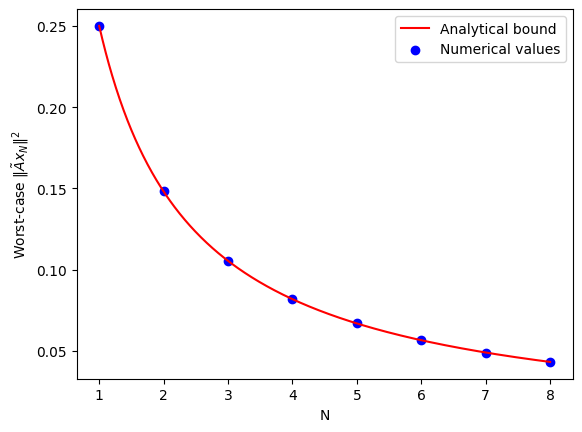

In [4]:
N_max = 8
R = pf.Parameter("R")
R_value = 1

opt_values = []
for N in range(1, N_max + 1):
    ctx_N = make_ctx_proximal_point_method(ctx_name=f"ctx_{N}", N=N)
    pb_plt = pf.PEPBuilder(ctx_N)
    pb_plt.add_initial_constraint(
        ((ctx_N["x_0"] - ctx_N["x_star"]) ** 2).le(R, name="initial_condition")
    )
    pb_plt.set_performance_metric((ctx_N[f"x_{N}"] - ctx_N[f"x_{N + 1}"]) ** 2)
    result = pb_plt.solve(resolve_parameters={"R": R_value})
    opt_values.append(result.opt_value)

iters = np.arange(1, N_max + 1)
cont_iters = np.arange(1, N_max + 0.01, 0.01)
bound_vals = np.array([1 / ((1 + 1 / t) ** t * (t + 1)) for t in cont_iters])
plt.plot(cont_iters, bound_vals, "r-", label="Analytical bound")
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $\|\tilde{A} x_N\|^2$")
plt.legend()

## Verification of convergence of PPM

In [5]:
def q_value(N):
    return sp.S(N) / sp.S(N + 1)


def tau_value(N):
    q = q_value(N)
    return q**N / sp.S(N + 1)


def tag_to_index(tag, N):
    if tag == "x_star":
        return N + 2
    return int(tag.split("_", 1)[1])

### For this example, we use the known information of the analytic PEP-style proof.

### The closed-form multipliers are
$$
\lambda_i := \lambda_{i,i+1} = 2q^{N-i}\frac{i}{N+1} \,\, (i=1,\dots,N), \qquad
\mu_i := \lambda_{i,\star} = 2q^{N-i}\frac{N-i}{(N+1)^2} \,\, (i=1,\dots,N), \qquad
\mu_{N+1} = \lambda_{N+1,\star} = \frac{2}{N+1}
$$
### where $q=N/(N+1)$.

In [6]:
def lamb(tag_i, tag_j, N):
    i = tag_to_index(tag_i, N)
    j = tag_to_index(tag_j, N)
    q = q_value(N)
    if 1 <= i <= N and j == i + 1:
        return sp.S(2) * q ** (N - i) * sp.S(i) / sp.S(N + 1)
    if tag_j == "x_star":
        if 1 <= i <= N:
            return sp.S(2) * q ** (N - i) * sp.S(N - i) / sp.S(N + 1) ** 2
        if i == N + 1:
            return sp.S(2) / sp.S(N + 1)
    return sp.S(0)


def relaxed_constraints(N):
    point_tags = [f"x_{i}" for i in range(1, N + 2)] + ["x_star"]
    return [
        f"A:{tag_i},{tag_j}"
        for tag_i, tag_j in itertools.combinations(point_tags, 2)
        if lamb(tag_i, tag_j, N) == 0
    ]

### The explicit square decomposition of $S$ is
$$
    S_N=\sum_{i=1}^{N}q^{N-i}\frac{i}{N}
    \left\|q(x_{i-1}-x_\star)-2q(x_i-x_\star)+(x_{i+1}-x_\star)\right\|^2.
$$
### This decomposition will be used in determining $\mathcal{J}_k$ in Step 1.

In [7]:
def sos_coeff(i, N):
    q = q_value(N)
    return q ** (N - i) * sp.S(i) / sp.S(N)


def sos_vector(ctx, i, N):
    q = q_value(N)
    x_star = ctx["x_star"]
    return (
        q * (ctx[f"x_{i - 1}"] - x_star)
        - sp.S(2) * q * (ctx[f"x_{i}"] - x_star)
        + (ctx[f"x_{i + 1}"] - x_star)
    )


def S_guess_expr(ctx, N):
    S_guess = pf.Scalar.zero()
    for i in range(1, N + 1):
        S_guess += sos_coeff(i, N) * sos_vector(ctx, i, N) ** 2
    return S_guess

### Sparse certificate for tight proof is obtained after relaxing the inactive interpolation constraints

In [8]:
N = sp.S(6)
R = pf.Parameter("R")
R_value = sp.S(1)

ctx_prf = make_ctx_proximal_point_method(ctx_name="ctx_prf", N=N)
pb_prf = pf.PEPBuilder(ctx_prf)
pb_prf.add_initial_constraint(
    ((ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2).le(R, name="initial_condition")
)
pb_prf.set_performance_metric((ctx_prf[f"x_{N}"] - ctx_prf[f"x_{N + 1}"]) ** 2)

# Relax the inactive interpolation constraints to expose the sparse closed-form certificate.
pb_prf.set_relaxed_constraints(relaxed_constraints(int(N)))

result = pb_prf.solve(resolve_parameters={"R": R_value})
print(result.opt_value)
print("expected:", sp.N(tau_value(N)))

0.05664443623666892
expected: 0.0566527795148523


### Store the solver output

In [9]:
tau_sol = result.dual_var_manager.dual_value("initial_condition")
lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(A)
S_sol = result.get_gram_dual_matrix()

In [10]:
lamb_sol.pprint()

<IPython.core.display.Math object>

In [11]:
S_sol.pprint()

<IPython.core.display.Math object>

### Verify the closed form formulas match the numerical certificates

In [12]:
lamb_cand = pf.pprint_labeled_matrix(
    lambda tag_i, tag_j: lamb(tag_i, tag_j, int(N)),
    lamb_sol.row_names,
    lamb_sol.col_names,
    return_matrix=True,
)
print(
    "Did we guess the right closed form of lambda?",
    np.allclose(lamb_cand, lamb_sol.matrix, atol=1e-3),
)

<IPython.core.display.Math object>

Did we guess the right closed form of lambda? True


In [13]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"R": R_value})
S_guess = S_guess_expr(ctx_prf, int(N))
S_guess_eval = np.array(pm.eval_scalar(S_guess).matrix, dtype=float)
S_sol_matrix = np.array(S_sol.matrix, dtype=float)
pf.pprint_labeled_matrix(S_guess_eval, S_sol.row_names, S_sol.col_names)
print(
    "Did we guess the right closed form of S?",
    np.allclose(S_guess_eval, S_sol_matrix, atol=1e-3),
)

<IPython.core.display.Math object>

Did we guess the right closed form of S? True


### Numerically check that the PEP-style proof is correct

In [14]:
certificate = pf.Scalar.zero()
for i in range(1, int(N) + 1):
    certificate += lamb(f"x_{i}", f"x_{i + 1}", int(N)) * A.interp_ineq(
        f"x_{i}", f"x_{i + 1}"
    )
for i in range(1, int(N) + 2):
    coeff = lamb(f"x_{i}", "x_star", int(N))
    if coeff != 0:
        certificate += coeff * A.interp_ineq(f"x_{i}", "x_star")

perf = (ctx_prf[f"x_{N}"] - ctx_prf[f"x_{N + 1}"]) ** 2
proof_residual = (
    perf
    - tau_value(N) * (ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2
    - certificate
    + S_guess
)
proof_residual_eval = pm.eval_scalar(proof_residual).inner_prod_coords.astype(float)
print(
    "Proof identity holds numerically?", np.allclose(proof_residual_eval, 0, atol=1e-8)
)
print("max residual:", np.max(np.abs(proof_residual_eval)))

Proof identity holds numerically? True
max residual: 1.1102230246251565e-16


---

## Step 1. Propose a candidate Lyapunov function

### We take $\mathcal{I}_0 = \mathcal{J}_0 = \emptyset, \,\, \mathcal{I}_k = \{(j,j+1):j=1,\dots,k\}\cup\{(j,\star):j=1,\dots,k\}$ and $\mathcal{J}_k = \{1,\dots,k\}$ for $k=1,\dots,N$.
### The last step will use only the monotonicity inequality for the pair $(N+1,\star)$.

In [15]:
lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
for step in range(1, int(N) + 1):
    partial_sum += lamb(f"x_{step}", f"x_{step + 1}", int(N)) * A.interp_ineq(
        f"x_{step}", f"x_{step + 1}"
    )
    coeff = lamb(f"x_{step}", "x_star", int(N))
    if coeff != 0:
        partial_sum += coeff * A.interp_ineq(f"x_{step}", "x_star")
    partial_sum -= sos_coeff(step, int(N)) * sos_vector(ctx_prf, step, int(N)) ** 2
    # if step == int(N):
    #     partial_sum += lamb(f"x_{int(N) + 1}", "x_star", int(N)) * A.interp_ineq(
    #         f"x_{int(N) + 1}", "x_star"
    #     )
    lyap.append(partial_sum)

## Step 2. Check for admissibility

### Sufficiency is immediate, so we check for rank concistency and conciseness
### Interior rank is constantly 3, except for the last two iterations

In [16]:
for k in range(len(lyap)):
    raw_rank = np.linalg.matrix_rank(
        pm.eval_scalar(lyap[k]).inner_prod_coords.astype(float), tol=1e-6
    )
    print(f"k={k}: rank(V_k)={raw_rank}")

k=0: rank(V_k)=0
k=1: rank(V_k)=3
k=2: rank(V_k)=3
k=3: rank(V_k)=3
k=4: rank(V_k)=3
k=5: rank(V_k)=2
k=6: rank(V_k)=3


## Step 3. Build a set of special candidate vectors

In [17]:
lyap_basis_candidate = ctx_prf.basis_vectors()
x = [ctx_prf[f"x_{i}"] for i in range(1, int(N) + 2)]
lyap_basis_candidate += x

base_count = len(lyap_basis_candidate)
for i, j in itertools.combinations(range(base_count), 2):
    tag = f"{lyap_basis_candidate[i].tag}-{lyap_basis_candidate[j].tag}"
    if tag in ctx_prf.tag_to_vectors_or_scalars:
        continue
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    diff.add_tag(tag)
    lyap_basis_candidate.append(diff)

In [18]:
print(lyap_basis_candidate)

[x_0, x_star, A(x_1), A(x_2), A(x_3), A(x_4), A(x_5), A(x_6), A(x_7), x_1, x_2, x_3, x_4, x_5, x_6, x_7, x_0-x_star, x_0-A(x_1), x_0-A(x_2), x_0-A(x_3), x_0-A(x_4), x_0-A(x_5), x_0-A(x_6), x_0-A(x_7), x_0-x_1, x_0-x_2, x_0-x_3, x_0-x_4, x_0-x_5, x_0-x_6, x_0-x_7, x_star-A(x_1), x_star-A(x_2), x_star-A(x_3), x_star-A(x_4), x_star-A(x_5), x_star-A(x_6), x_star-A(x_7), x_star-x_1, x_star-x_2, x_star-x_3, x_star-x_4, x_star-x_5, x_star-x_6, x_star-x_7, A(x_1)-A(x_2), A(x_1)-A(x_3), A(x_1)-A(x_4), A(x_1)-A(x_5), A(x_1)-A(x_6), A(x_1)-A(x_7), A(x_1)-x_1, A(x_1)-x_2, A(x_1)-x_3, A(x_1)-x_4, A(x_1)-x_5, A(x_1)-x_6, A(x_1)-x_7, A(x_2)-A(x_3), A(x_2)-A(x_4), A(x_2)-A(x_5), A(x_2)-A(x_6), A(x_2)-A(x_7), A(x_2)-x_1, A(x_2)-x_2, A(x_2)-x_3, A(x_2)-x_4, A(x_2)-x_5, A(x_2)-x_6, A(x_2)-x_7, A(x_3)-A(x_4), A(x_3)-A(x_5), A(x_3)-A(x_6), A(x_3)-A(x_7), A(x_3)-x_1, A(x_3)-x_2, A(x_3)-x_3, A(x_3)-x_4, A(x_3)-x_5, A(x_3)-x_6, A(x_3)-x_7, A(x_4)-A(x_5), A(x_4)-A(x_6), A(x_4)-A(x_7), A(x_4)-x_1, A(x_4)-x_2, A

## Step 4. Find a basis of $\mathbf{V}_k$ within the candidate vectors

In [19]:
for k in range(len(lyap)):
    print(
        f"V_{k}:",
        lu.vectors_in_column_space(
            lyap[k],
            lyap_basis_candidate,
            ctx_prf,
            resolve_parameters=pm.resolve_parameters,
            rtol=1e-5,
            atol=1e-5,
        ),
    )

V_0: []
V_1: [A(x_1), A(x_2), x_0-x_star, x_0-x_1, x_0-x_2, x_star-x_1, x_star-x_2, A(x_1)-A(x_2), x_1-x_2]
V_2: [A(x_3), x_0-x_star, x_0-x_2, x_0-x_3, x_star-x_2, x_star-x_3, x_2-x_3]
V_3: [A(x_4), x_0-x_star, x_0-x_3, x_0-x_4, x_star-x_3, x_star-x_4, x_3-x_4]
V_4: [A(x_5), x_0-x_star, x_0-x_4, x_0-x_5, x_star-x_4, x_star-x_5, x_4-x_5]
V_5: [x_0-x_star]
V_6: [A(x_7), x_0-x_star, x_0-x_6, x_0-x_7, x_star-x_6, x_star-x_7, x_6-x_7]


In [20]:
for k in range(1, len(lyap)):
    aligned_special_vectors_k = lu.vectors_in_column_space(
        lyap[k],
        lyap_basis_candidate,
        ctx_prf,
        resolve_parameters=pm.resolve_parameters,
        rtol=1e-5,
        atol=1e-5,
    )

    print(f"V_{k}:")
    best_vectors, best_coefficients = lu.find_basis_with_sparsest_coefficients(
        lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels_k = [str(v) for v in best_vectors]
    pf.pprint_labeled_matrix(best_coefficients, labels_k, labels_k)

V_1:


<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

V_3:


...

<IPython.core.display.Math object>

V_5:
No feasible independent subset can represent V.


<IPython.core.display.Math object>

V_6:


<IPython.core.display.Math object>

### The above computation suggests that each $V_k$ contains the term $-\tau_N \|x_0 - x_\star\|^2$, and the remaining rank-2 terms collapse to rank-1 when $k=N-1$.
### For convenience, we analyze $\widetilde{V}_k = V_k + \tau_N \|x_0 - x_\star\|^2$

In [21]:
translated_lyap = [
    V + tau_value(N) * (ctx_prf["x_0"] - ctx_prf["x_star"]) ** 2 for V in lyap
]

for k in range(len(lyap)):
    translated_rank = np.linalg.matrix_rank(
        pm.eval_scalar(translated_lyap[k]).inner_prod_coords.astype(float), tol=1e-6
    )
    print(f"k={k}: rank(translated V_k)={translated_rank}")

k=0: rank(translated V_k)=1
k=1: rank(translated V_k)=2
k=2: rank(translated V_k)=2
k=3: rank(translated V_k)=2
k=4: rank(translated V_k)=2
k=5: rank(translated V_k)=1
k=6: rank(translated V_k)=2


In [22]:
for k in range(1, len(lyap)):
    aligned_special_vectors_k = lu.vectors_in_column_space(
        translated_lyap[k],
        lyap_basis_candidate,
        ctx_prf,
        resolve_parameters=pm.resolve_parameters,
        rtol=1e-5,
        atol=1e-5,
    )

    print(f"V_{k}:")
    best_vectors, best_coefficients = lu.find_basis_with_sparsest_coefficients(
        translated_lyap[k],
        aligned_special_vectors_k,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels_k = [str(v) for v in best_vectors]
    pf.pprint_labeled_matrix(best_coefficients, labels_k, labels_k)

V_1:


<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

V_3:


...

<IPython.core.display.Math object>

V_5:


<IPython.core.display.Math object>

V_6:


<IPython.core.display.Math object>

### We can hypothesize the Lyapunov function of the form $\widetilde{V}_k = a_k \|\tilde{A} x_{k+1}\|^2 + b_k \langle \tilde{A} x_{k+1} , x_{k} - x_\star \rangle + c_k \|x_k - x_\star\|^2$ where $a_0 = b_0 = 0$, $c_0 = \tau_N$, and $a_N = 1$, $b_N = c_N = 0$.
### It seems when $k=N-1$, the coefficients satisfy $b_k^2 = 4a_k c_k$ and the vector quadratic form becomes a perfect square.

---

## Step 5. Analytic proof

### Symbolically determine the translated Lyapunov coefficients

### We solve $\widetilde{V}_k - \widetilde{V}_{k+1} - \lambda_{k+1} \langle \tilde{A}x_{k+2},\tilde{A}x_{k+1}-\tilde{A}x_{k+2}\rangle - \mu_{k+1} \langle x_{k+1}-x_\star,\tilde{A}x_{k+1}\rangle - q^{N-k-1}\frac{k+1}{N} \|q(x_k-x_\star)-2q(x_{k+1}-x_\star)+(x_{k+2}-x_\star)\|^2=0$ for $a_k,b_k,c_k,a_{k+1},b_{k+1},c_{k+1}$.

In [23]:
ctx_ppm_lyap = pf.PEPContext("ppm_monotone_lyap_finder").set_as_current()

xk_minus_xstar = pf.Vector(is_basis=True, tags=["x_k-x_star"])
Ax_kp1 = pf.Vector(is_basis=True, tags=["Ax_{k+1}"])
Ax_kp2 = pf.Vector(is_basis=True, tags=["Ax_{k+2}"])

N_param = pf.Parameter("N")
k_param = pf.Parameter("k")
q_param = N_param / (N_param + sp.S(1))

a_k = pf.Parameter("a_k")
a_kp1 = pf.Parameter("a_{k+1}")
b_k = pf.Parameter("b_k")
b_kp1 = pf.Parameter("b_{k+1}")
c_k = pf.Parameter("c_k")
c_kp1 = pf.Parameter("c_{k+1}")

xkp1_minus_xstar = xk_minus_xstar - Ax_kp1
xkp2_minus_xstar = xkp1_minus_xstar - Ax_kp2

lambda_kp1 = (
    sp.S(2)
    * q_param ** (N_param - k_param - sp.S(1))
    * (k_param + sp.S(1))
    / (N_param + sp.S(1))
)
mu_kp1 = (
    sp.S(2)
    * q_param ** (N_param - k_param - sp.S(1))
    * (N_param - k_param - sp.S(1))
    / (N_param + sp.S(1)) ** 2
)
s_kp1 = q_param ** (N_param - k_param - sp.S(1)) * (k_param + sp.S(1)) / N_param

V_k = a_k * Ax_kp1**2 + b_k * Ax_kp1 * xk_minus_xstar + c_k * xk_minus_xstar**2
V_kp1 = (
    a_kp1 * Ax_kp2**2 + b_kp1 * Ax_kp2 * xkp1_minus_xstar + c_kp1 * xkp1_minus_xstar**2
)
I_kp1 = -(Ax_kp2 * (Ax_kp1 - Ax_kp2))
J_kp1 = -(xkp1_minus_xstar * Ax_kp1)
z_kp1 = (
    q_param * xk_minus_xstar - sp.S(2) * q_param * xkp1_minus_xstar + xkp2_minus_xstar
)

diff = V_kp1 - V_k - lambda_kp1 * I_kp1 - mu_kp1 * J_kp1 + s_kp1 * z_kp1**2

### Convert the identity into a linear system

In [24]:
basis = ctx_ppm_lyap.basis_vectors()
row_index = [str(v) for v in basis]
row_index

a_k_sp, a_kp1_sp, b_k_sp, b_kp1_sp, c_k_sp, c_kp1_sp = sp.symbols(
    "a_k a_{k+1} b_k b_{k+1} c_k c_{k+1}"
)
N_sp, k_sp = sp.symbols("N k", integer=True, positive=True)

pm_lyap = pf.ExpressionManager(
    ctx_ppm_lyap,
    resolve_parameters={
        "a_k": a_k_sp,
        "a_{k+1}": a_kp1_sp,
        "b_k": b_k_sp,
        "b_{k+1}": b_kp1_sp,
        "c_k": c_k_sp,
        "c_{k+1}": c_kp1_sp,
        "N": N_sp,
        "k": k_sp,
    },
)

diff_matrix_array = pm_lyap.eval_scalar(diff).inner_prod_coords
diff_matrix_sympify = sp.Matrix(diff_matrix_array).applyfunc(
    lambda entry: sp.factor(sp.together(sp.nsimplify(entry)))
)
pf.pprint_labeled_matrix(
    np.array(diff_matrix_sympify.tolist(), dtype=object),
    row_index,
    row_index,
    precision=None,
)

<IPython.core.display.Math object>

### Solve the coefficient equations and derive the unique solution that makes the formulas for coefficients consistent in $k$

In [25]:
unknowns = (a_k_sp, a_kp1_sp, b_k_sp, b_kp1_sp, c_k_sp, c_kp1_sp)
solution_set = sp.linsolve(list(diff_matrix_sympify), unknowns)
solution_tuple = next(iter(solution_set))
parametric_solution = {
    unknown: sp.factor(sp.together(sp.nsimplify(expression)))
    for unknown, expression in zip(unknowns, solution_tuple)
}

print("Parametric solution:")
display(
    Math(
        r"\begin{aligned}"
        + r"\\".join(
            sp.latex(sp.Eq(unknown, parametric_solution[unknown]))
            for unknown in unknowns
        )
        + r"\end{aligned}"
    )
)

q_sp = N_sp / (N_sp + sp.S(1))
b_kp1_formula = (
    sp.S(2)
    * q_sp ** (N_sp - k_sp - sp.S(1))
    * (k_sp + sp.S(1))
    / (N_sp * (N_sp + sp.S(1)))
)
b_k_from_shift = sp.factor(sp.together(b_kp1_formula.subs(k_sp, k_sp - sp.S(1))))

print("Use the formula for b_{k+1} and shift k -> k-1:")
display(
    Math(
        r"\begin{aligned}"
        + sp.latex(sp.Eq(b_kp1_sp, b_kp1_formula))
        + r"\\"
        + sp.latex(sp.Eq(b_k_sp, b_k_from_shift))
        + r"\end{aligned}"
    )
)

c_kp1_from_shifted_b = sp.solve(
    sp.Eq(parametric_solution[b_k_sp], b_k_from_shift),
    c_kp1_sp,
)[0]
c_kp1_from_shifted_b = sp.factor(sp.together(sp.simplify(c_kp1_from_shifted_b)))

print("Solving the parametric b_k equation for c_{k+1} gives:")
display(Math(sp.latex(sp.Eq(c_kp1_sp, c_kp1_from_shifted_b))))

selected_solution = {
    unknown: sp.factor(
        sp.together(
            sp.simplify(
                parametric_solution[unknown].subs({c_kp1_sp: c_kp1_from_shifted_b})
            )
        )
    )
    for unknown in unknowns
}

closed_form_solution = {
    a_k_sp: q_sp ** (N_sp - k_sp) * k_sp * (N_sp - sp.S(1)) / (N_sp * (N_sp + sp.S(1))),
    a_kp1_sp: q_sp ** (N_sp - k_sp - sp.S(1))
    * (k_sp + sp.S(1))
    * (N_sp - sp.S(1))
    / (N_sp * (N_sp + sp.S(1))),
    b_k_sp: b_k_from_shift,
    b_kp1_sp: b_kp1_formula,
    c_k_sp: q_sp ** (N_sp - k_sp) * (N_sp - k_sp) / (N_sp * (N_sp + sp.S(1))),
    c_kp1_sp: c_kp1_from_shifted_b,
}
closed_form_solution = {
    unknown: sp.factor(sp.together(sp.simplify(expression)))
    for unknown, expression in closed_form_solution.items()
}

print("Selected closed form:")
display(
    Math(
        r"\begin{aligned}"
        + r"\\".join(
            sp.latex(sp.Eq(unknown, closed_form_solution[unknown]))
            for unknown in unknowns
        )
        + r"\end{aligned}"
    )
)
print(
    "Selected form belongs to the solution family?",
    all(
        sp.simplify(selected_solution[unknown] - closed_form_solution[unknown]) == 0
        for unknown in unknowns
    ),
)

verification_matrix = diff_matrix_sympify.subs(selected_solution)
verification_matrix = verification_matrix.applyfunc(
    lambda entry: sp.factor(sp.together(sp.simplify(entry)))
)
display(verification_matrix)
print(
    "Symbolic identity verified?",
    verification_matrix == sp.zeros(*verification_matrix.shape),
)

Parametric solution:


<IPython.core.display.Math object>

Use the formula for b_{k+1} and shift k -> k-1:


<IPython.core.display.Math object>

Solving the parametric b_k equation for c_{k+1} gives:


...

Selected closed form:


<IPython.core.display.Math object>

Selected form belongs to the solution family? True


Matrix([
[0, 0, 0],
[0, 0, 0],
[0, 0, 0]])

Symbolic identity verified? True
